# Degrau de Potencial — Controle Difusional Reversível

Considera-se uma transferência de elétrons reversível entre as espécies $O$ e $R$:

$$O + ne^- \rightleftharpoons R$$

Assumindo eletrodo planar, o transporte é descrito pela segunda lei de Fick para cada espécie:

$$\frac{\partial C_O}{\partial \tau} = D_O \frac{\partial^2 C_O}{\partial y^2} \tag{1.0a}$$

$$\frac{\partial C_R}{\partial \tau} = D_R \frac{\partial^2 C_R}{\partial y^2} \tag{1.0b}$$

Assumindo R inicialmente ausente e pré-equilíbrio no potencial padrão, as condições iniciais são:

$$
\theta_i = 1 .
$$ 

$$C_O(y,0) = C_O^{eq} = 0.5 \tag{1.1a}$$

$$C_R(y,0) = C_R^{eq} = 0.5 \tag{1.1b}$$

A difusão semi-infinita é aplicada no seio da solução:

$$\lim_{y \to \infty} C_O(y, \tau) = C_O^{eq} \tag{1.2a}$$

$$\lim_{y \to \infty} C_R(y, \tau) = C_R^{eq} \tag{1.2b}$$

Os fluxos na interface eletrodo/solução são determinados pela cinética de Butler-Volmer:

$$
\eta = \frac{F}{RT}(E-E^0)
$$

$$
J = K^0 \left[ C_R(0,\tau) e^{(1-\alpha)\eta} - C_O(0,\tau) e^{-\alpha \eta} \right]
$$

$$-D_O\frac{\partial C_O(0, \tau)}{\partial y}= J \quad \text{para} \quad \tau > 0 \tag{1.3a}$$

$$ -D_R\frac{\partial C_R(0, \tau)}{\partial y} = -J \quad \text{para} \quad \tau > 0 \tag{1.3b}$$

Introduzindo as variáveis adimensionais:

$$
\begin{align}
x = \frac{y}{\sqrt{D\tau_s}}, &\quad t = \frac{\tau}{\tau_s} \\
c_{O,R} = \frac{C_{O,R}}{C_O^*}, &\quad \eta = E - E^0 \\
r_D = \frac{D_R}{D_O}, &\quad k^0 = K^0 \sqrt{\frac{\tau_s}{D_O}}\\
j &= \frac{J}{c_O^* \sqrt{D/\tau_s}}
\end{align}
$$
as equações tornam-se, para $t \geq 0$ e $0 \leq x \leq 6$:

$$\frac{\partial c_O}{\partial t} = \frac{\partial^2 c_O}{\partial x^2} \tag{1.0a}$$

$$\frac{\partial c_R}{\partial t} = r_D \frac{\partial^2 c_R}{\partial x^2} \tag{1.0b}$$

$$c_O(x, 0) = \frac{\theta_i}{1+\theta_i} \tag{1.1a}$$

$$c_R(x, 0) = \frac{1}{1+\theta_i} \tag{1.1b}$$

$$\lim_{x \to \infty} c_O(x, t) = \frac{\theta_i}{1+\theta_i} \tag{1.2a}$$

$$\lim_{x \to \infty} c_R(x, t) = \frac{\theta_i}{1+\theta_i} \tag{1.2b}$$

As condições de fluxo na interface ficam:

$$
j = k^0 \left[ c_R(0,t) e^{(1-\alpha)\eta} - c_O(0,t) e^{-\alpha \eta} \right]
$$

$$-\frac{\partial c_O(0, t)}{\partial x} = j \quad \text{para} \quad t > 0 \tag{1.3a}$$

$$ -r_D\frac{\partial c_R(0, t)}{\partial x} = -j \quad \text{para} \quad t > 0 \tag{1.3b}$$


A densidade de corrente é proporcional ao fluxo difusional na superfície do eletrodo:

$$I(\tau) = nFD \left(\frac{\partial C_O}{\partial y}\right)_{y=0} = nFD\frac{C_O^*}{\sqrt{D\tau}} \left(\frac{\partial c_O}{\partial x}\right)_{x=0}$$

Definindo a corrente adimensional:

$$i(t) = \frac{I(\tau)\sqrt{D\tau_s}}{nFD C_O^*} = \left( \frac{\partial c_O(x,t)}{\partial x} \right)_{x=0}$$

## Bibliotecas:

In [1]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt
from scipy import special
from ipywidgets import Text, Button, HBox, VBox, Output
from IPython.display import display, clear_output

## Definindo o Modelo:

In [2]:
model = pybamm.BaseModel()

concentration_o = pybamm.Variable("Concentração de O", domain="electrolyte")
concentration_r = pybamm.Variable("Concentração de R", domain="electrolyte")

overpotential = pybamm.InputParameter(
    "Sobrepotencial Aplicado [V]"
)
standard_rate_constant = pybamm.InputParameter(
    "Constante de velocidade padrão"
)

transfer_coefficient = pybamm.InputParameter(
    "Coeficiente de transferência"
)

faraday = pybamm.Parameter(
    "Constante de Faraday [C.mol-1]"
)

gas_constant = pybamm.Parameter(
    "Constante dos Gases [J.K-1.mol-1]"
)

temperature = pybamm.Parameter(
    "Temperatura [K]"
)

r_D = pybamm.Parameter(
    "Razão entre os coeficientes de difusão"
)  # DR/DO

flux_o = -pybamm.grad(concentration_o)   # fluxo difusional de O
flux_r = -r_D*pybamm.grad(concentration_r)   # fluxo difusional de R

model.rhs = {
    concentration_o: -pybamm.div(flux_o),
    concentration_r: -pybamm.div(flux_r),
}


# condições iniciais de pré-equilíbrio em E_i = E^0
model.initial_conditions = {
    concentration_o: pybamm.Scalar(0.5),
    concentration_r: pybamm.Scalar(0.5),
}

#condições de fluxo na interface
nernst_factor = faraday / (gas_constant * temperature)   # f = F/(RT)
theta_anodic  = pybamm.exp(
    (1-transfer_coefficient)*nernst_factor * overpotential
)
theta_cathodic  = pybamm.exp(
    -(transfer_coefficient)*nernst_factor * overpotential
)
cR_surface = pybamm.boundary_value(concentration_r, "left")
cO_surface = pybamm.boundary_value(concentration_o, "left")

flux_F = standard_rate_constant*(
    cR_surface*theta_anodic - cO_surface*theta_cathodic
)

current_bv = flux_F

gradient_O_surface = -flux_F
gradient_R_surface = flux_F / r_D

model.boundary_conditions = {
    concentration_o: {
        "left":  (gradient_O_surface, "Neumann"), #eq. 1.3a
        "right": (pybamm.Scalar(0.5),    "Dirichlet"),  # eq. 1.2a: c_O(∞,t) = 1
    },
    concentration_r: {
        "left":  (gradient_R_surface,    "Neumann"), #eq. 1.3b
        "right": (pybamm.Scalar(0.5),    "Dirichlet"),  # eq. 1.2b: c_R(∞,t) = 0
    },
}

model.variables = {
    "Concentração de O": concentration_o,
    "Concentração de R": concentration_r,
    "Fluxo de O":        flux_o,
    "Fluxo de R":        flux_r,
    "Corrente cinética": current_bv
}

param = pybamm.ParameterValues(
    {
        "Constante de Faraday [C.mol-1]":     96485.3,
        "Constante dos Gases [J.K-1.mol-1]":  8.31446,
        "Temperatura [K]":                    298.15,
        "Razão entre os coeficientes de difusão": 1,
    }
)

## Geometria

In [3]:
# ── Geometria ─────────────────────────────────────────────────────────

x_variable = pybamm.SpatialVariable(
    "x", domain=["electrolyte"], coord_sys="cartesian"
)

geometry = {
    "electrolyte": {x_variable: {"min": pybamm.Scalar(0), "max": pybamm.Scalar(6)}}
}

## Malha

In [4]:
submesh_types  = {
    "electrolyte": pybamm.MeshGenerator(
        pybamm.Exponential1DSubMesh,
        submesh_params={
            "side": "left",
            "stretch": 5,
        },
    )
}
variable_points = {x_variable: 1600}
mesh            = pybamm.Mesh(geometry, submesh_types, variable_points)

## Discretização

In [5]:
# ── Discretização ─────────────────────────────────────────────────────────────
spatial_methods = {"electrolyte": pybamm.FiniteVolume()}
discretisation  = pybamm.Discretisation(mesh, spatial_methods)

param.process_model(model)
param.process_geometry(geometry)
discretisation.process_model(model)

## Solver:

In [6]:
solver  = pybamm.IDAKLUSolver()

In [12]:
t = np.geomspace(1e-6, 1, 1000)

overpotential_i = 0.1

currents_k0 = []
times_k0 = []

standard_rate_constants = [0.01, 0.1, 1, 10]
for k0_i in standard_rate_constants:

    solution_i = solver.solve(
        model,
        t,
        inputs={
            "Sobrepotencial Aplicado [V]": overpotential_i,
            "Constante de velocidade padrão": k0_i,
             "Coeficiente de transferência": 0.5,
        }
    )

    current_i = solution_i["Corrente cinética"]

    currents_k0.append(current_i(solution_i.t))
    times_k0.append(solution_i.t)

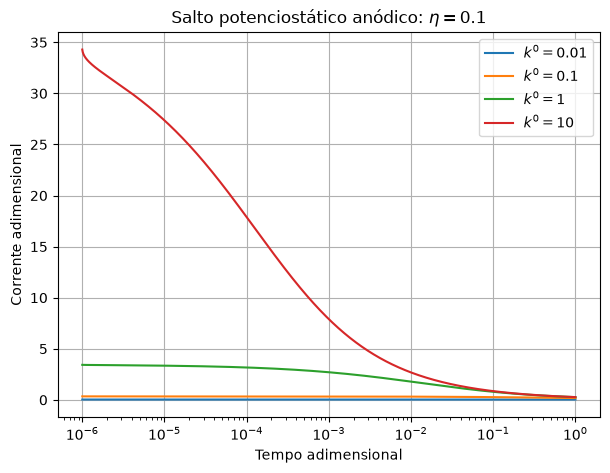

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))

for k0_i, t_i, current_i in zip(
    standard_rate_constants,
    times_k0,
    currents_k0
):
    ax.plot(
        t_i,
        current_i,
        label=fr"$k^0 = {k0_i:g}$"
    )

ax.set_xscale("log")

ax.set_xlabel("Tempo adimensional")
ax.set_ylabel("Corrente adimensional")
ax.set_title(r"Salto potenciostático anódico: $\eta=0.1$")

ax.legend()
ax.grid(True)

plt.show()

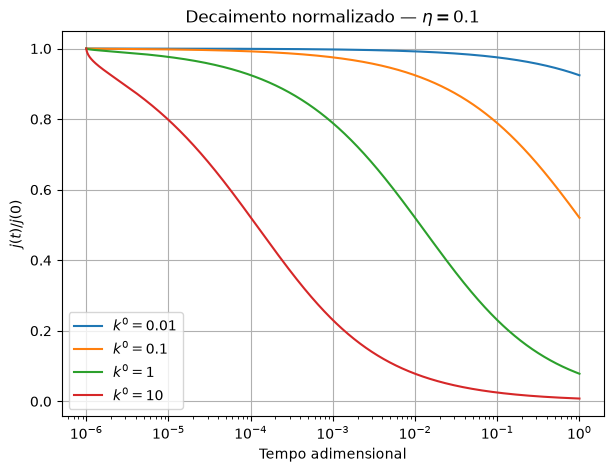

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))

for k0_i, t_i, current_i in zip(
    standard_rate_constants,
    times_k0,
    currents_k0
):
    ax.plot(
        t_i,
        current_i / current_i[0],
        label=fr"$k^0 = {k0_i:g}$"
    )

ax.set_xscale("log")

ax.set_xlabel("Tempo adimensional")
ax.set_ylabel(r"$j(t)/j(0)$")
ax.set_title(r"Decaimento normalizado — $\eta=0.1$")

ax.legend()
ax.grid(True)

plt.show()